<a href="https://colab.research.google.com/github/Ngatiah/WebHooks/blob/main/Year_prediction_analysis_task_CAT_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## REG.NO: COM/2393/23    NAME: WAMUYU IVY NGATIA

# 🎵 Year Prediction MSD — EDA & Regression Modeling
**Dataset**: Million Song Dataset — Year Prediction (via OpenML)  
**Goal**: Predict the **release year** of a song from 90 audio features  
**Size**: 515,345 samples × 90 numeric features  
**Target**: Year (1922–2011) — approximately uniform


The **Year Prediction MSD dataset** is derived from the **Million Song Dataset (MSD)**, a large-scale collection of audio features and metadata for contemporary music tracks. The task is to predict the **release year** of a song (ranging from 1922 to 2011) based purely on audio characteristics — no artist name, title, or lyrics are used.

## Features

All **90 features are real-valued numeric** and derived from the **timbre** of the audio signal — a perceptual quality that distinguishes different sounds even at the same pitch and volume. They split into two groups:

- **First 12**: Timbre segment averages — the mean of 12 timbre components across all segments of the song
- **Last 78**: Timbre covariance — the upper triangle of the 12×12 covariance matrix, capturing how timbre components vary together throughout the track

## Target

The target is the **release year** as a continuous integer (1922–2011). The distribution is roughly uniform from the 1960s onward with far fewer songs in earlier decades.

## Dataset Split & Size

The dataset comes with an **official predefined train/test split** recommended by UCI — **463,715 training samples** and **51,630 test samples**.  It has no missing values and requires only `StandardScaler` preprocessing before training.


## 1. Install & Import Dependencies

In [2]:
# Uncomment if running for the first time
# !pip install scikit-learn pandas numpy matplotlib seaborn torch
! pip uninstall -y torch sympy && pip install torch scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('All imports successful ✅')


Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl (530.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 8.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.25.0+cpu requires torch==2.10.0, but you have torch 2.11.0 which is incompatible.
torchaudio 2.10.0+cpu requires torch==2.10.0, but you have torch 2.11.0 which is incompatible.
All imports successful ✅


In [3]:
# ************
# Setting and using a seed for reprodicibility
seed = 42
# Numpy
np.random.seed(seed)

# PyTorch (CPU)
torch.manual_seed(seed)
#PyTorch (GPU/CUDA)
if torch.cuda.is_available():
	torch.cuda.manual_seed(seed)
	# ************

## 2. Load the Dataset
> ⚠️ This dataset is ~500K rows. Fetching may take 1–3 minutes on first run (cached after that).

In [4]:
print('Fetching Year Prediction MSD from OpenML...')
ds = fetch_openml(name='year', version=1, as_frame=True)
# ds = fetch_openml(name='year', version=1, as_frame=True, cache=False)
# ds = fetch_openml(data_id=46672, as_frame=True)

# ds = fetch_openml(
#     data_id=46672,
#     as_frame=True,
#     # parser="pandas"   # 👈 bypass ARFF + checksum issues
#     cache=False
# )

Fetching Year Prediction MSD from OpenML...


In [5]:

X = ds.data
y = ds.target.astype(float)

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Feature dtypes : {X.dtypes.value_counts().to_dict()}')
print(f'Missing values : {X.isnull().sum().sum()}')

Features shape : (515345, 90)
Target shape   : (515345,)
Feature dtypes : {dtype('float64'): 90}
Missing values : 0


In [6]:
X.shape

(515345, 90)

In [7]:
X.head()

,1,2,3,4,5,6,7,8,9,10,...,81,82,83,84,85,86,87,88,89,90
0,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,-2.46783,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,4.59210,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,1.39518,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,-6.36304,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,0.93609,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [8]:
y.shape

(515345,)

In [9]:
y.head()

,year
0,2001.0
1,2001.0
2,2001.0
3,2001.0
4,2001.0


## 3. Basic Inspection

In [10]:
df = X.copy()
df['year'] = y

print('First 5 rows:')
display(df.head())
print('\nTarget statistics:')
display(y.describe())


First 5 rows:


,1,2,3,4,5,6,7,8,9,10,...,82,83,84,85,86,87,88,89,90,year
0,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,-2.46783,...,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327,2001.0
1,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,4.59210,...,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061,2001.0
2,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,1.39518,...,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345,2001.0
3,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,-6.36304,...,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382,2001.0
4,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,0.93609,...,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903,2001.0



Target statistics:


,year
count,515345.000000
mean,1998.397082
std,10.931046
min,1922.000000
25%,1994.000000
50%,2002.000000
75%,2006.000000
max,2011.000000


## 4. Feature Structure — Timbre Means vs Covariances

In [11]:
# The 90 features break down as:
# - First 12:  Timbre average (mean of 12 timbre components over segments)
# - Last 78:   Timbre covariance (upper triangle of 12x12 covariance matrix)

timbre_avg = X.columns[:12].tolist()
timbre_cov = X.columns[12:].tolist()

print(f'Timbre average features  : {len(timbre_avg)}  → {timbre_avg[:4]}...')
print(f'Timbre covariance features: {len(timbre_cov)}  → {timbre_cov[:4]}...')
print(f'Total features           : {len(timbre_avg) + len(timbre_cov)}')


Timbre average features  : 12  → ['1', '2', '3', '4']...
Timbre covariance features: 78  → ['13', '14', '15', '16']...
Total features           : 90


## 5. Target Distribution (Release Year)

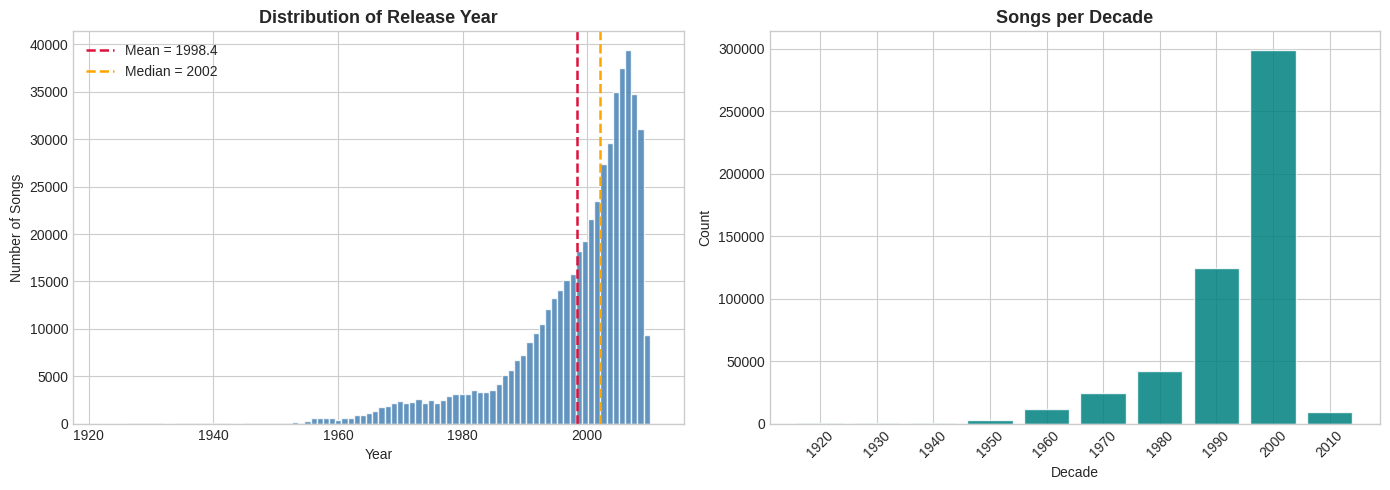

Skewness: -1.732  (close to 0 = symmetric ✅)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y, bins=90, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Release Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Songs')
axes[0].axvline(y.mean(), color='crimson', linestyle='--', linewidth=1.8, label=f'Mean = {y.mean():.1f}')
axes[0].axvline(y.median(), color='orange', linestyle='--', linewidth=1.8, label=f'Median = {y.median():.0f}')
axes[0].legend()

# Songs per decade
decade_counts = y.apply(lambda yr: int(yr // 10) * 10).value_counts().sort_index()
axes[1].bar(decade_counts.index.astype(str), decade_counts.values, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Songs per Decade', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Skewness: {y.skew():.3f}  (close to 0 = symmetric ✅)')


## 6. Feature Statistics Overview

Feature value ranges (min, max, std):


,min,max,std
count,90.000000,90.000000,90.000000
mean,-3051.790348,5704.328101,190.156900
std,3430.647907,9094.024271,265.560893
min,-14861.695350,60.345350,4.370848
25%,-4382.998505,1029.446428,49.781157
50%,-1811.789315,2894.183195,119.839313
75%,-252.280710,6595.927387,217.279733
max,21.214350,65735.779530,1749.367690


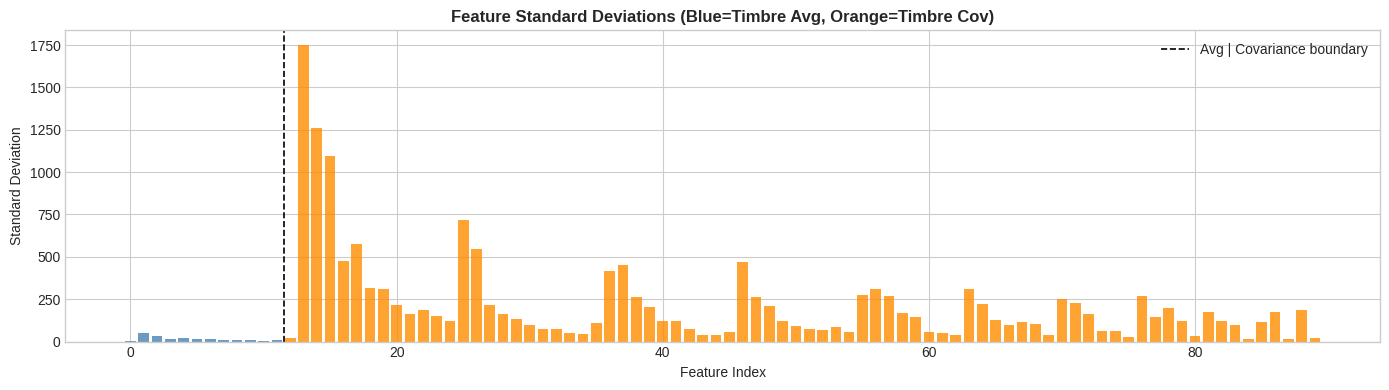

In [13]:
print('Feature value ranges (min, max, std):')
summary = X.agg(['min', 'max', 'std']).T
display(summary.describe())

# Plot feature std deviation to see dynamic range
plt.figure(figsize=(14, 4))
plt.bar(range(len(X.columns)), X.std().values, color=['steelblue' if i < 12 else 'darkorange' for i in range(90)], edgecolor='none', alpha=0.8)
plt.axvline(11.5, color='black', linestyle='--', linewidth=1.2, label='Avg | Covariance boundary')
plt.legend()
plt.xlabel('Feature Index')
plt.ylabel('Standard Deviation')
plt.title('Feature Standard Deviations (Blue=Timbre Avg, Orange=Timbre Cov)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_std.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Top Features Correlated with Year

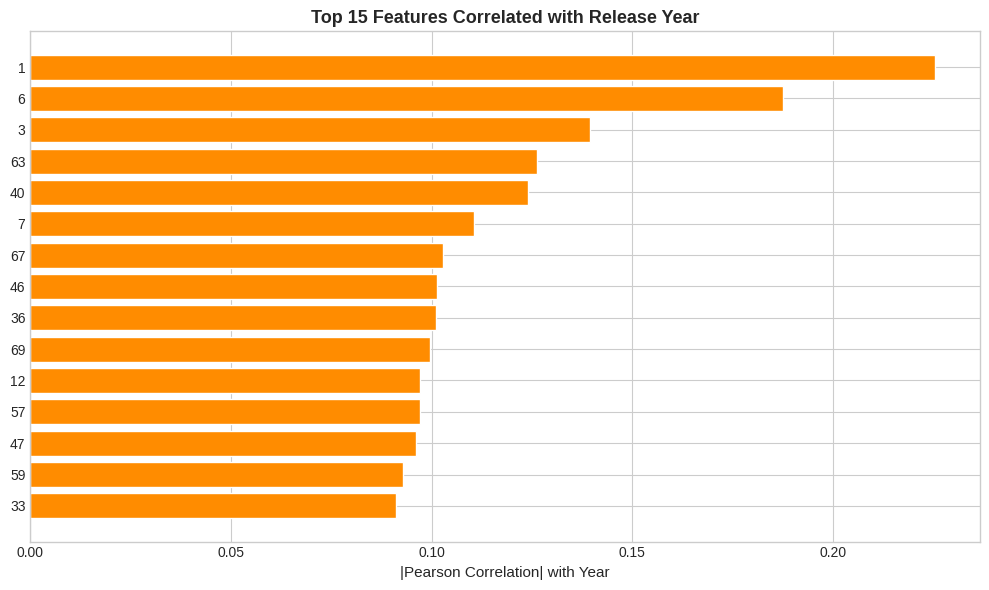

Top 5 features:
 1     0.225374
6     0.187443
3     0.139541
63    0.126348
40    0.123974
dtype: float64


In [14]:
correlations = X.corrwith(y).abs().sort_values(ascending=False)
top15 = correlations.head(15)

colors = ['steelblue' if int(feat.split('_')[-1] if '_' in feat else 99) < 12 else 'darkorange'
          for feat in top15.index]

plt.figure(figsize=(10, 6))
plt.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('|Pearson Correlation| with Year', fontsize=11)
plt.title('Top 15 Features Correlated with Release Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 features:\n', top15.head())


## 8. PCA — Variance Explained by Components

Components to explain 90% variance: 1
Components to explain 95% variance: 1


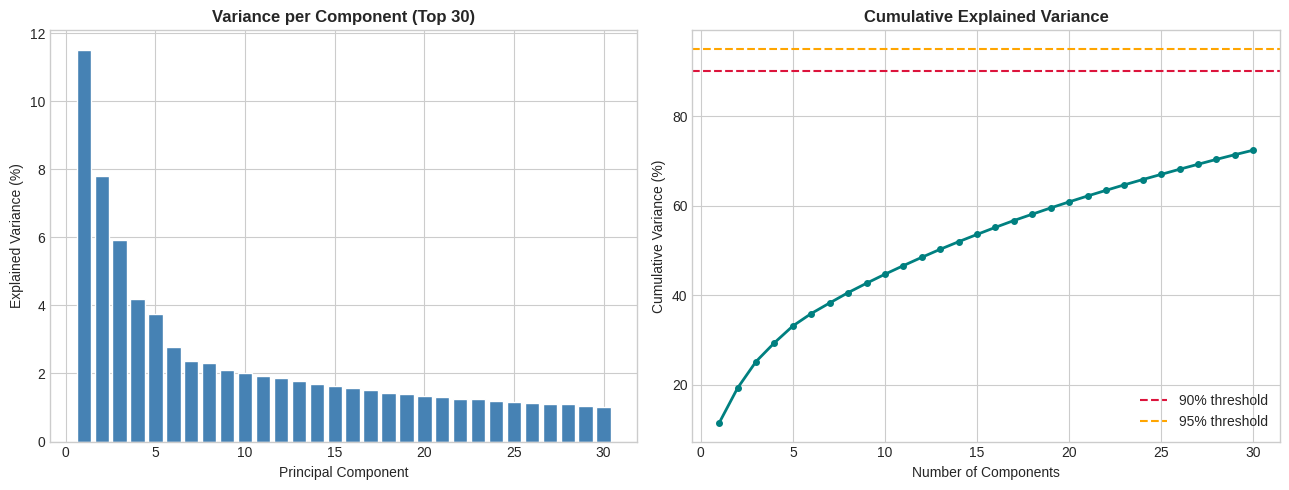

In [15]:
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

pca = PCA(n_components=30)
pca.fit(X_scaled_pca)

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, 31), pca.explained_variance_ratio_ * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Variance per Component (Top 30)', fontsize=12, fontweight='bold')

axes[1].plot(range(1, 31), cumvar, marker='o', markersize=4, color='teal', linewidth=2)
axes[1].axhline(90, color='crimson', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].axhline(95, color='orange', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend()

n90 = np.argmax(cumvar >= 90) + 1
n95 = np.argmax(cumvar >= 95) + 1
print(f'Components to explain 90% variance: {n90}')
print(f'Components to explain 95% variance: {n95}')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Train/Test Split & Scaling
Use the **official split**: first 463,715 rows = train, last 51,630 = test (as per UCI). Do not perform your own split.
X_train and y_train are dataframes holding your training set, while X_test and y_test will hold your testing set.

In [16]:
X = ds.data
y = ds.target.astype(float)

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Feature dtypes : {X.dtypes.value_counts().to_dict()}')
print(f'Missing values : {X.isnull().sum().sum()}')

Features shape : (515345, 90)
Target shape   : (515345,)
Feature dtypes : {dtype('float64'): 90}
Missing values : 0


In [17]:
X.head()

,1,2,3,4,5,6,7,8,9,10,...,81,82,83,84,85,86,87,88,89,90
0,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,-2.46783,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,4.59210,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,1.39518,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,-6.36304,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,0.93609,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [18]:
y.head()

,year
0,2001.0
1,2001.0
2,2001.0
3,2001.0
4,2001.0


In [19]:
X.columns

Index(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13',
       '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25',
       '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37',
       '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49',
       '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61',
       '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73',
       '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85',
       '86', '87', '88', '89', '90'],
      dtype='object')

In [20]:
#Use the Official UCI train-test split
# Do not do your own split
TRAIN_SIZE = 463715

X_train, X_test = X.iloc[:TRAIN_SIZE], X.iloc[TRAIN_SIZE:]
y_train, y_test = y.iloc[:TRAIN_SIZE], y.iloc[TRAIN_SIZE:]

print("X_train:", X_train.shape)



print(f'X_train : {X_train.shape}')
print(f'X_test   : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test : {y_test.shape}')

X_train: (463715, 90)
X_train : (463715, 90)
X_test   : (51630, 90)
y_train : (463715,)
y_test : (51630,)


## TASK:
    1. Do scaling and create Data loaders
    2. Build and train your neural network (this is a large dataset, use Google Colab GPUs).
    3. The neural networks should have less than 200, 000 parameters. Print this count out.
    4. Traning time should be less than  20 minutes.
    4. Apply regularizatioin techniques
    3. Plot and interpret loss curves. Check for overfitting.
    4. Save the model.
Use MSE as the loss function.
For evaluation, convert the model MSE to RMSE (take the square root of final MSE) - this is what you will print and report. <br>Aim for RMSE of between 7.8 and 12)

Submit this work by ***5.00PM 10th April, 2026*** to ekiprop@mu.ac.ke by email (the finished notebook) <br>
Also share the Google Colab notebook with ekiprop@mu.ac.ke

Do not forget to include your Registration Number and Name at the top of the notebook.


In [21]:
'''
Feature Scaling
'''
# Feature scaler
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled  = X_scaler.transform(X_test)

# Target scaler
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1))

print(f"Training x samples : {X_train_scaled.shape[0]}")
print(f"Test x samples     : {X_test_scaled.shape[0]}")
print(f"Features         : {X_train_scaled.shape[1]}")
print(f"Training y samples : {y_train_scaled.shape[0]}")
print(f"Test y samples     : {y_test_scaled.shape[0]}")
print(f"Features         : {y_train_scaled.shape[1]}")
print(f"\nAfter scaling — Training feature mean (should be ~0): {X_train_scaled.mean(axis=0).round(2)[:5]}")


Training x samples : 463715
Test x samples     : 51630
Features         : 90
Training y samples : 463715
Test y samples     : 51630
Features         : 1

After scaling — Training feature mean (should be ~0): [-0.  0.  0. -0. -0.]


In [22]:
'''
Dataloaders
'''
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset
class RegressionDataset(Dataset):
    """
    A generic Dataset for regression tasks.
    Accepts numpy arrays X (features) and y (continuous targets).
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # shape: (N, 1)
        self.y = torch.tensor(y, dtype=torch.float32)


    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Create dataset objects
train_dataset_MSD = RegressionDataset(X_train_scaled, y_train_scaled)
test_dataset_MSD  = RegressionDataset(X_test_scaled,  y_test_scaled)

# Wrap in DataLoaders
train_loader_b = DataLoader(train_dataset_MSD, batch_size=256, shuffle=True)
test_loader_b  = DataLoader(test_dataset_MSD,  batch_size=256, shuffle=False)

print(f"Train batches: {len(train_loader_b)}")
print(f"Test batches : {len(test_loader_b)}")

# Inspect one batch
for bX, by in train_loader_b:
    print(f"\nBatch X shape: {bX.shape}")   # (128, 90)
    print(f"Batch y shape: {by.shape}")     # (128, 1)

Streaming output truncated to the last 5000 lines.
Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Size([256, 1])

Batch X shape: torch.Size([256, 90])
Batch y shape: torch.Siz

In [23]:
input_size = X_train_scaled.shape[1]
input_size


90

In [24]:
'''
A6. Building the Regression Model
Using nn.Sequential
nn.MSELoss() as loss function
First layer : nn.Linear(input_size,128)
Last layer: nn.Linear(16, 1) — single neuron outputting one continuous value
'''


'\nA6. Building the Regression Model\nUsing nn.Sequential\nnn.MSELoss() as loss function\nFirst layer : nn.Linear(input_size,128)\nLast layer: nn.Linear(16, 1) — single neuron outputting one continuous value\n'

In [36]:
import torch.nn as nn
model_MSD = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.2),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(p=0.2),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(p=0.1),

    nn.Linear(32,16),
    nn.BatchNorm1d(16),
    nn.ReLU(),

    nn.Linear(16, 1)
)
# .to(device)

print(model_MSD)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model_MSD.parameters()):,}")

Sequential(
  (0): Linear(in_features=90, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.1, inplace=False)
  (12): Linear(in_features=32, out_features=16, bias=True)
  (13): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU()
  (15): Linear(in_features=16, out_features=1, bias=True)
)

Total trainable parameters: 23,009


In [38]:
'''
Training the model
'''
import torch.optim as optim
import time
criterion_MSD = nn.MSELoss()

optimizer_MSD = optim.AdamW(
    model_MSD.parameters(),
    lr=5e-4,
    weight_decay=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_MSD, mode='min', factor=0.5, patience=5
)

# early stopping features
patience = 12
best_val_loss = float('inf')
counter = 0

# num_epochs = 200
# num_epochs = 100
# num_epochs = 60

num_epochs = 25
'''
START TIMER
'''
start_time = time.time()

train_losses_b, val_losses_b = [], []

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model_MSD.train() # Crucial: Enables Dropout and BatchNorm updates
    epoch_train_loss = 0.0
    for bX, by in train_loader_b:
        preds = model_MSD(bX)
        loss = criterion_MSD(preds, by)

        optimizer_MSD.zero_grad()
        loss.backward()
        optimizer_MSD.step()
        epoch_train_loss += loss.item()

    # --- VALIDATION PHASE ---
    model_MSD.eval() # Crucial: Disables Dropout, locks BatchNorm
    epoch_val_loss = 0.0
    with torch.no_grad():
        for bX, by in test_loader_b:
            preds = model_MSD(bX)
            epoch_val_loss += criterion_MSD(preds, by).item()

    avg_train_loss = epoch_train_loss / len(train_loader_b)
    avg_val_loss = epoch_val_loss / len(test_loader_b)

    train_losses_b.append(avg_train_loss)
    val_losses_b.append(avg_val_loss)

    # Step the scheduler
    scheduler.step(avg_val_loss)

    # EARLY STOPPING & SAVING MODEL
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model_MSD.state_dict(), 'best_model_msd.pth')
        counter = 0
        print(f"Epoch {epoch+1}: New best Val MSE: {avg_val_loss:.4f} (Saved)")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # if (epoch + 1) % 5 == 0:
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:>3}] | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")

# --- END TIMER ---
end_time = time.time()
total_duration = end_time - start_time

print(f"\n" + "-"*30)
print(f"Total Training Time: {total_duration:.2f} seconds")
print(f"Average Time per Epoch: {(total_duration/num_epochs):.4f} seconds")
print("-"*30)

Epoch 1: New best Val MSE: 0.6419 (Saved)
Epoch 4: New best Val MSE: 0.6415 (Saved)
Epoch [ 10] | Train MSE: 0.6008 | Val MSE: 0.6418
Epoch 11: New best Val MSE: 0.6409 (Saved)
Epoch 12: New best Val MSE: 0.6407 (Saved)
Epoch 15: New best Val MSE: 0.6396 (Saved)
Epoch [ 20] | Train MSE: 0.5877 | Val MSE: 0.6416

------------------------------
Total Training Time: 605.56 seconds
Average Time per Epoch: 24.2224 seconds
------------------------------


In [ ]:
'''
Epoch 1: New best Val MSE: 0.6419 (Saved)
Epoch 4: New best Val MSE: 0.6415 (Saved)
Epoch [ 10] | Train MSE: 0.6008 | Val MSE: 0.6418
Epoch 11: New best Val MSE: 0.6409 (Saved)
Epoch 12: New best Val MSE: 0.6407 (Saved)
Epoch 15: New best Val MSE: 0.6396 (Saved)
Epoch [ 20] | Train MSE: 0.5877 | Val MSE: 0.6416
'''


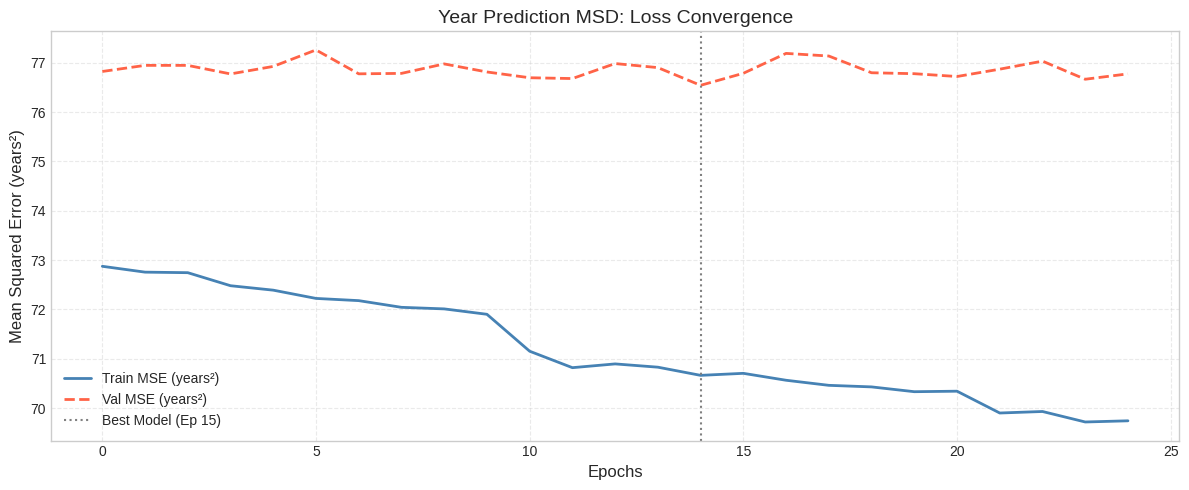

Minimum Validation MSE: 6.9969 years
Maximum Validation MSE: 7.0625 years
Minimum Validation RMSE: 8.7489 years
Maximum Validation RMSE: 8.7899 years


In [45]:
'''
Visualizing training and validation loss (MSE)
'''
y_std = y_scaler.scale_[0]

# Convert MSE from scaled space to real-world 'years squared' space
# Formula: MSE_real = MSE_scaled * (std_dev^2)
train_losses_years = [l * (y_std ** 2) for l in train_losses_b]
val_losses_years   = [l * (y_std ** 2) for l in val_losses_b]

plt.figure(figsize=(12, 5))
plt.plot(train_losses_years, label='Train MSE (years²)', color='steelblue', linewidth=2)
plt.plot(val_losses_years, label='Val MSE (years²)', color='tomato', linestyle='--', linewidth=2)

best_epoch = val_losses_years.index(min(val_losses_years))
plt.axvline(x=best_epoch, color='gray', linestyle=':', label=f'Best Model (Ep {best_epoch+1})')

plt.title("Year Prediction MSD: Loss Convergence", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Mean Squared Error (years²)", fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# Print the final MSE and RMSE
min_mse = min(val_losses_b) * y_std
max_mse = max(val_losses_b) * y_std
print(f"Minimum Validation MSE: {min_mse:.4f} years")
print(f"Maximum Validation MSE: {max_mse:.4f} years")
min_rmse = (min(val_losses_b) ** 0.5) * y_std
max_rmse = (max(val_losses_b) ** 0.5) * y_std
print(f"Minimum Validation RMSE: {min_rmse:.4f} years")
print(f"Maximum Validation RMSE: {max_rmse:.4f} years")



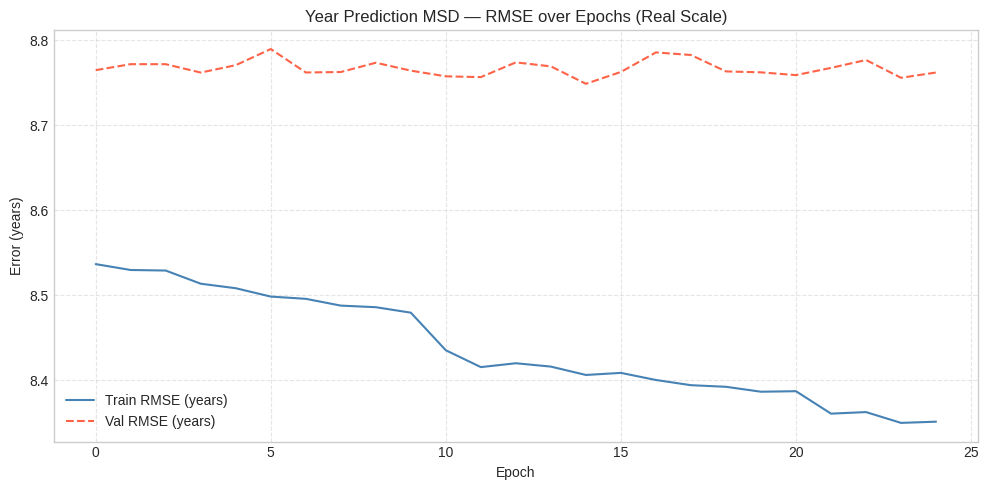

In [46]:
# convert scaled MSE → RMSE in real years
train_rmse = [np.sqrt(l) * y_scaler.scale_[0] for l in train_losses_b]
val_rmse   = [np.sqrt(l) * y_scaler.scale_[0] for l in val_losses_b]

plt.figure(figsize=(10, 5))

plt.plot(train_rmse, label='Train RMSE (years)', color='steelblue')
plt.plot(val_rmse, label='Val RMSE (years)', color='tomato', linestyle='--')

plt.title("Year Prediction MSD — RMSE over Epochs (Real Scale)")
plt.xlabel("Epoch")
plt.ylabel("Error (years)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [47]:
model_MSD.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for bX, by in test_loader_b:
        preds = model_MSD(bX)

        all_preds.append(preds.cpu().numpy())
        all_true.append(by.cpu().numpy())

# stack
all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true)

# convert back to real years
y_pred_real = y_scaler.inverse_transform(all_preds)
y_true_real = y_scaler.inverse_transform(all_true)

# RMSE in REAL units (years)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))

print("+" * 30)
print(f"RMSE (Years): {rmse:.2f}")
print("+" * 30)



++++++++++++++++++++++++++++++
RMSE (Years): 8.72
++++++++++++++++++++++++++++++


In [48]:
print(f"True Year Range: {y_true_real.min():.0f} to {y_true_real.max():.0f}")
print(f"Pred Year Range: {y_pred_real.min():.0f} to {y_pred_real.max():.0f}")

True Year Range: 1927 to 2010
Pred Year Range: 1966 to 2008
